In [23]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{\r\n    "username":"niharikabarthwal",\r\n    "key":"KGAT_ec2924bb5ced4dcb83cac88e73565df7"\r\n}'}

In [25]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets list

ref                                                              title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
nalisha/job-salary-prediction-dataset                            Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000           8198        193                1  
ssssws/chocolate-sales-dataset-2023-2024                         Chocolate Sales Dataset 2023 - 2024                   24420255  2026-03-07 04:58:02.387000          11905        187                1  
kienngx/nemotron-30b-competition-trainingdata-cot-labels         Nemotron-30B competition trainingdata (CoT+labels)     3903114  2026-03-24 01:42:23.850000            721         33               

In [ ]:
import kagglehub

path = kagglehub.dataset_download("deepnewbie/flir-thermal-images-dataset")
print("Dataset at:", path)

100%|██████████| 15.3G/15.3G [02:40<00:00, 102MB/s] 

Extracting files...


Dataset at: /root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1


In [26]:
import os
os.listdir("/root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1/FLIR_ADAS_1_3")

['ReadMe.txt',
 'val',
 '.ReadMe.txt.swp',
 'ADAS User License Agreement (26.Jul.2018) (Final).pdf',
 'train',
 'video',
 'README - FLIR ADAS Dataset V1_3.pdf']

In [ ]:
!pip install opencv-python
!pip install tqdm
!pip install scikit-learn

In [ ]:
import cv2
import os
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [27]:
dataset_path = "/root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1/FLIR_ADAS_1_3"

images_path = os.path.join(dataset_path,"train")
annotation_file = dataset_path + "/train/thermal_annotations.json"

print(os.listdir(images_path)[:5])

['Annotated_thermal_8_bit', 'RGB', 'thermal_8_bit', 'thermal_16_bit', 'thermal_annotations.json']


In [28]:
thermal_folder = "/content/thermal_8_bit"
json_path = "/content/thermal_annotations.json"

In [29]:
import json

with open(annotation_file,'r') as f:
    annotations = json.load(f)

print(len(annotations['annotations']))

67844


In [30]:
import os
print(os.listdir("/content"))

['.config', 'kaggle (1).json', 'kaggle.json', 'sample_data']


In [31]:
dataset_path = "/root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1/FLIR_ADAS_1_3"

for root, dirs, files in os.walk(dataset_path + "/train"):
    print("ROOT:", root)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    print("------")
    break

ROOT: /root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1/FLIR_ADAS_1_3/train
DIRS: ['Annotated_thermal_8_bit', 'RGB', 'thermal_8_bit', 'thermal_16_bit']
FILES: ['thermal_annotations.json']
------


In [32]:
for cat in annotations['categories']:
    print(cat)

{'name': 'person', 'id': 1, 'supercategory': 'unknown'}
{'name': 'bicycle', 'id': 2, 'supercategory': 'unknown'}
{'name': 'car', 'id': 3, 'supercategory': 'unknown'}
{'name': 'motorcycle', 'id': 4, 'supercategory': 'unknown'}
{'name': 'airplane', 'id': 5, 'supercategory': 'unknown'}
{'name': 'bus', 'id': 6, 'supercategory': 'unknown'}
{'name': 'train', 'id': 7, 'supercategory': 'unknown'}
{'name': 'truck', 'id': 8, 'supercategory': 'unknown'}
{'name': 'boat', 'id': 9, 'supercategory': 'unknown'}
{'name': 'traffic light', 'id': 10, 'supercategory': 'unknown'}
{'name': 'fire hydrant', 'id': 11, 'supercategory': 'unknown'}
{'name': 'stop sign', 'id': 12, 'supercategory': 'unknown'}
{'name': 'parking meter', 'id': 13, 'supercategory': 'unknown'}
{'name': 'bench', 'id': 14, 'supercategory': 'unknown'}
{'name': 'bird', 'id': 15, 'supercategory': 'unknown'}
{'name': 'cat', 'id': 16, 'supercategory': 'unknown'}
{'name': 'dog', 'id': 17, 'supercategory': 'unknown'}
{'name': 'horse', 'id': 18, '

In [33]:
person_id = None

for cat in annotations['categories']:

    if cat['name'] == "person":
        person_id = cat['id']

print("Person class id:",person_id)

Person class id: 1


In [34]:
human_frame_ids = set()

for ann in annotations['annotations']:

    if ann['category_id'] == person_id:
        human_frame_ids.add(ann['image_id'])

print("Human frames:",len(human_frame_ids))

Human frames: 5838


In [35]:
image_map = {}

for img in annotations['images']:
    image_map[img['id']] = img['file_name']

print(list(image_map.items())[:5])

[(0, 'thermal_8_bit/FLIR_00001.jpeg'), (1, 'thermal_8_bit/FLIR_00002.jpeg'), (2, 'thermal_8_bit/FLIR_00003.jpeg'), (3, 'thermal_8_bit/FLIR_00004.jpeg'), (4, 'thermal_8_bit/FLIR_00005.jpeg')]


In [36]:
human_images = []

for img_id in human_frame_ids:

    file_name = image_map[img_id]
    img_path = os.path.join(images_path,file_name)

    if os.path.exists(img_path):
        human_images.append(img_path)

print("Total human images:",len(human_images))

Total human images: 5838


In [37]:
human_images = human_images[:8000]

print("Images used:", len(human_images))

Images used: 5838


In [38]:
import cv2
import numpy as np

def preprocess(img_path):

    img = cv2.imread(img_path,0)   # grayscale thermal image

    img = cv2.resize(img,(128,128))   # smaller resolution

    img = img / 255.0

    return img.astype(np.float32)

In [39]:
import os
import numpy as np

sequence_length = 8
save_dir = "/content/sequences"

os.makedirs(save_dir, exist_ok=True)

count = 0

for i in range(len(human_images) - sequence_length):

    seq = []

    for j in range(sequence_length):

        img = preprocess(human_images[i+j])
        seq.append(img)

    seq = np.array(seq)

    np.save(f"{save_dir}/seq_{count}.npy", seq)

    count += 1

print("Total sequences saved:", count)

Total sequences saved: 5830


In [40]:
sample = np.load("/content/sequences/seq_0.npy")

print(sample.shape)

(8, 128, 128)


In [41]:
import os
print(os.listdir("/content"))

['.config', 'kaggle (1).json', 'sequences', 'kaggle.json', 'sample_data']


In [42]:
import os

seq_folder = "/content/sequences"

files = os.listdir(seq_folder)

print("Total sequences:", len(files))
print("Example files:", files[:5])

Total sequences: 5830
Example files: ['seq_1587.npy', 'seq_5322.npy', 'seq_453.npy', 'seq_773.npy', 'seq_934.npy']


In [43]:
import os, shutil, random

seq_dir = "/content/sequences"
files = os.listdir(seq_dir)

random.shuffle(files)

split = int(0.8 * len(files))

train_files = files[:split]
val_files = files[split:]

train_dir = "/content/train_sequences"
val_dir = "/content/val_sequences"

shutil.rmtree(train_dir, ignore_errors=True)
shutil.rmtree(val_dir, ignore_errors=True)

os.makedirs(train_dir)
os.makedirs(val_dir)

for f in train_files:
    shutil.copy(os.path.join(seq_dir,f), os.path.join(train_dir,f))

for f in val_files:
    shutil.copy(os.path.join(seq_dir,f), os.path.join(val_dir,f))

In [44]:
import os
import numpy as np
import cv2
from collections import Counter

In [45]:
def compute_motion_magnitude(sequence):

    mags = []

    for i in range(len(sequence)-1):

        frame1 = sequence[i][0]
        frame2 = sequence[i+1][0]

        frame1 = (frame1*255).astype(np.uint8)
        frame2 = (frame2*255).astype(np.uint8)

        flow = cv2.calcOpticalFlowFarneback(
            frame1,
            frame2,
            None,
            0.5,
            3,
            15,
            3,
            5,
            1.2,
            0
        )

        mag,_ = cv2.cartToPolar(flow[...,0],flow[...,1])

        mags.append(np.mean(mag))

    return np.mean(mags)

In [46]:
motions = []

train_files = sorted(os.listdir(train_dir))

for f in train_files:
    seq = np.load(os.path.join(train_dir,f))
    motions.append(compute_motion_magnitude(seq))

motions = np.array(motions)

print("Motion samples:", len(motions))

Motion samples: 4664


In [47]:
median_motion = np.median(motions)
print("Median motion:", median_motion)

Median motion: 2.1819376e-18


In [48]:
train_labels = []

for f in train_files:
    seq = np.load(os.path.join(train_dir,f))
    m = compute_motion_magnitude(seq)

    if m < median_motion:
        train_labels.append(0)
    else:
        train_labels.append(1)

print("Train labels:", len(train_labels))

Train labels: 4664


In [49]:
val_files = sorted(os.listdir(val_dir))

val_labels = []

for f in val_files:
    seq = np.load(os.path.join(val_dir,f))
    m = compute_motion_magnitude(seq)

    if m < median_motion:
        val_labels.append(0)
    else:
        val_labels.append(1)

print("Val labels:", len(val_labels))

Val labels: 1166


In [50]:
from collections import Counter

print("Train:", Counter(train_labels))
print("Val:", Counter(val_labels))

Train: Counter({0: 2332, 1: 2332})
Val: Counter({1: 599, 0: 567})


In [51]:
import torch
from torch.utils.data import Dataset, DataLoader

class ThermalDataset(Dataset):

    def __init__(self, folder, labels):

        self.folder = folder
        self.files = sorted(os.listdir(folder))
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        path = os.path.join(self.folder, self.files[idx])

        seq = np.load(path).astype(np.float32)

        label = self.labels[idx]

        return torch.tensor(seq), torch.tensor(label)

In [52]:
train_dataset = ThermalDataset(train_dir, train_labels)
val_dataset = ThermalDataset(val_dir, val_labels)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 583
Val batches: 146


In [53]:
import cv2
import numpy as np
import torch

def optical_flow_batch(sequences):

    batch_flows = []

    for seq in sequences:

        flows = []

        # Move the tensor to CPU before converting to numpy
        seq = seq.detach().cpu().numpy()

        for i in range(len(seq)-1):

            # Corrected: pass the entire 2D frame, not a slice
            f1 = (seq[i]*255).astype(np.uint8)
            f2 = (seq[i+1]*255).astype(np.uint8)

            flow = cv2.calcOpticalFlowFarneback(
                f1,
                f2,
                None,
                0.5,
                3,
                15,
                3,
                5,
                1.2,
                0
            )

            flow = np.transpose(flow,(2,0,1))

            flows.append(flow)

        batch_flows.append(np.array(flows))

    return torch.tensor(np.array(batch_flows)).float()

In [54]:
import torch.nn as nn

class FlowCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(2,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

    def forward(self,x):

        x = self.net(x)

        return x.view(x.size(0),-1)

In [55]:
class TemporalTransformer(nn.Module):

    def __init__(self):

        super().__init__()

        encoder = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            batch_first=True
        )

        self.trans = nn.TransformerEncoder(encoder, num_layers=2)

        self.fc = nn.Linear(64,4)

    def forward(self,x):

        x = self.trans(x)

        x = torch.mean(x,dim=1)

        return self.fc(x)

In [56]:
class HybridModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.cnn = FlowCNN()
        self.transformer = TemporalTransformer()

    def forward(self, seq_batch):

        flows = optical_flow_batch(seq_batch)

        flows = flows.to(device)

        B = flows.shape[0]
        T = flows.shape[1]
        C = flows.shape[2]
        H = flows.shape[3]
        W = flows.shape[4]

        flows = flows.reshape(B*T, C, H, W)   # ⭐ SAFE reshape

        feats = self.cnn(flows)

        feats = feats.reshape(B, T, -1)

        out = self.transformer(feats)

        return out

In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HybridModel().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [58]:
print("Train files:", len(os.listdir(train_dir)))
print("Train labels:", len(train_labels))

print("Val files:", len(os.listdir(val_dir)))
print("Val labels:", len(val_labels))

Train files: 4664
Train labels: 4664
Val files: 1166
Val labels: 1166


In [59]:
epochs = 25

loss_history = []  # Initialize list to store loss per epoch

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for seqs,labels in train_loader:

        seqs = seqs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(seqs)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_epoch_loss = total_loss/len(train_loader)
    loss_history.append(avg_epoch_loss) # Store the average loss for the epoch
    print("Epoch",epoch,"Loss",avg_epoch_loss)

Epoch 0 Loss 0.6860216462898417
Epoch 1 Loss 0.6014302145453301
Epoch 2 Loss 0.5513666601624743
Epoch 3 Loss 0.5342302809039684
Epoch 4 Loss 0.529037780919165
Epoch 5 Loss 0.5134541043056428
Epoch 6 Loss 0.5080593535309181
Epoch 7 Loss 0.4992295459781871
Epoch 8 Loss 0.49347044303885457
Epoch 9 Loss 0.4806977976145507
Epoch 10 Loss 0.4785800609437311
Epoch 11 Loss 0.47198755814219423
Epoch 12 Loss 0.4793768143904352
Epoch 13 Loss 0.47069513520439943
Epoch 14 Loss 0.4552093697759749
Epoch 15 Loss 0.44412824475744783
Epoch 16 Loss 0.4514287980097645
Epoch 17 Loss 0.42796900231985446
Epoch 18 Loss 0.4223963761411441
Epoch 19 Loss 0.4126165596253876
Epoch 20 Loss 0.4042154775475556
Epoch 21 Loss 0.40453704368597854
Epoch 22 Loss 0.4042008816556906
Epoch 23 Loss 0.3903714159398146
Epoch 24 Loss 0.3847235490026441


In [60]:
model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for seqs,labels in val_loader:

        seqs = seqs.to(device)
        labels = labels.to(device)

        outputs = model(seqs)

        _,pred = torch.max(outputs,1)

        total += labels.size(0)
        correct += (pred==labels).sum().item()

        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100*correct/total

print("Validation Accuracy:",accuracy)

Validation Accuracy: 82.0754716981132


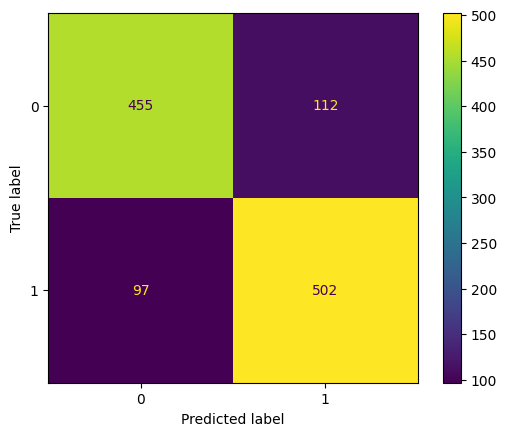

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [62]:
torch.save(model.state_dict(),"HAR_final_model.pth")
print("Model Saved")

Model Saved


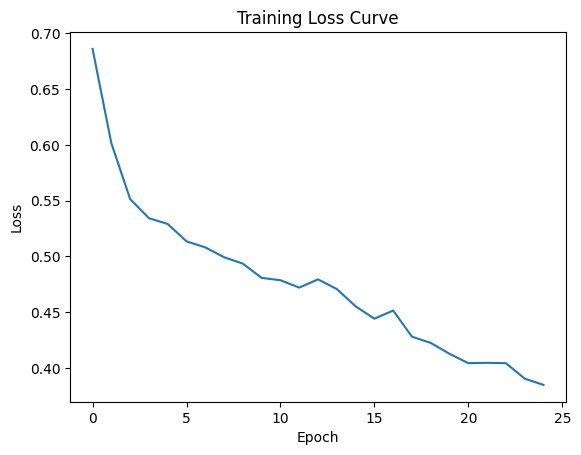

In [63]:
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [64]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       567
           1       0.82      0.84      0.83       599

    accuracy                           0.82      1166
   macro avg       0.82      0.82      0.82      1166
weighted avg       0.82      0.82      0.82      1166



In [65]:
model.load_state_dict(torch.load("HAR_final_model.pth", map_location=device))
model.eval()

HybridModel(
  (cnn): FlowCNN(
    (net): Sequential(
      (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): AdaptiveAvgPool2d(output_size=(1, 1))
    )
  )
  (transformer): TemporalTransformer(
    (trans): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        

In [66]:
import numpy as np
import os

seq_path = os.path.join(val_dir, os.listdir(val_dir)[0])   # take one validation sample

seq = np.load(seq_path).astype(np.float32)

In [67]:
import torch

seq_tensor = torch.tensor(seq).unsqueeze(0).to(device)   # shape → (1, S, 1, 128,128)

In [68]:
class_names = {
    0: "Walking",
    1: "Running",
    2: "Standing",
    3: "Falling"
}

In [69]:
with torch.no_grad():
    output = model(seq_tensor)
    _, pred = torch.max(output, 1)

pred_label = class_names[pred.item()]

print("Predicted Activity:", pred_label)

Predicted Activity: Running


In [70]:
print(seq.shape)

(8, 128, 128)


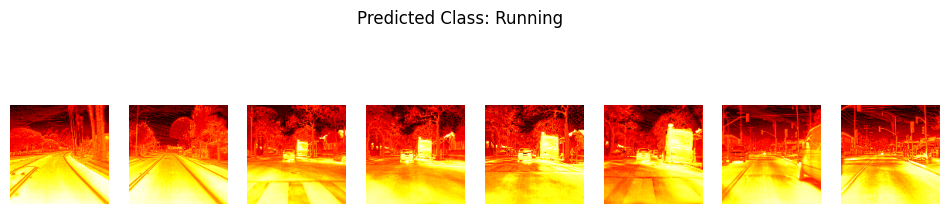

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,3))

for i in range(len(seq)):

    plt.subplot(1, len(seq), i+1)
    plt.imshow(seq[i], cmap='hot')
    plt.axis('off')

plt.suptitle(f"Predicted Class: {class_names[pred.item()]}")
plt.show()